# Transform Yield Data

Reads raw maize yield CSVs for each location and reshapes them from wide to long form.
Columns like `A-N0 Zrnje` are split into `management` (A/B/C), `fertilization` (N0–N3), and `product` (Zrnje/Slama).
Outputs are saved to `data/interim/yield/`.

In [1]:
import pandas as pd

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_observed_yield

In [17]:
locations = {
    "jablje": config.RAW_YIELD_DIR / "maize-jablje.csv",
    "rakican": config.RAW_YIELD_DIR / "maize-rakican.csv",
}

product_translations = {
    "zrnje": "grain",
    "slama": "straw",
}

for location, path in locations.items():
    wide = pd.read_csv(path, sep=";", dtype={"Leto": int})

    long = wide.melt(id_vars="Leto", var_name="column", value_name="yield")

    # Column format: "{management}-{fertilization} {product}"
    # e.g. "A-N0 Zrnje" -> management=A, fertilization=N0, product=Zrnje
    split = long["column"].str.extract(r"^(?P<management>[A-C])-(?P<fertilization>N\d) (?P<product>.+)$")
    long = pd.concat([long.drop(columns="column"), split], axis=1)
    long = long.assign(product=long["product"].str.strip().str.lower().map(product_translations))

    long["location"] = location
    long = long.rename(columns={"Leto": "year"})
    long = long[["location", "year", "management", "fertilization", "product", "yield"]]
    long = long.dropna(subset=["yield"]).reset_index(drop=True)

    long.loc[:, "yield"] = long["yield"] / 1000

    group_cols = ["location", "year", "management", "fertilization"]
    pivoted = (
        long[long["product"].isin(["grain", "straw"])]
        .pivot_table(index=group_cols, columns="product", values="yield")
        .reset_index()
    )
    pivoted.loc[:, "biomass_yield"] = pivoted["grain"] + pivoted["straw"]
    pivoted.loc[:, "hi_yield"] = pivoted["grain"] / pivoted["biomass_yield"]

    biomass = pivoted[group_cols + ["biomass_yield"]].rename(columns={"biomass_yield": "yield"}).assign(product="biomass")
    hi = pivoted[group_cols + ["hi_yield"]].rename(columns={"hi_yield": "yield"}).assign(product="hi")

    long = pd.concat([long, biomass, hi], ignore_index=True)

    out_path = config.INTERIM_YIELD_DIR / f"maize-{location}.csv"
    long.to_csv(out_path, index=False)
    print(f"Saved {len(long)} rows to {out_path}")

Saved 1240 rows to /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/data/interim/yield/maize-jablje.csv
Saved 1140 rows to /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/data/interim/yield/maize-rakican.csv


/var/folders/c1/1wgwqccj039_jffwp6hv0n9m0000gn/T/ipykernel_3357/1879413220.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 6.163  5.558  6.702  2.884  4.139  2.967  2.547  3.405  2.394  5.041
  4.22   0.426  3.401  2.989  8.494  5.026  0.634  1.149  4.637  3.533
  2.787  8.362  1.693  2.223  4.972  5.33   4.28   5.383  1.623  3.586
  6.571 10.628  9.919  8.219  3.811  4.813  3.11   3.52   4.592  2.527
  3.441  6.266  1.601  3.795  2.563 10.266  4.5    2.278  1.434  4.394
  3.862 10.309  6.757  3.571  2.9    4.091  6.929  4.71   5.794  2.882
  6.221  8.769  7.83  10.422 12.013  8.27  10.369  8.889  9.76  10.134
  6.792 12.08   7.525  6.108 11.081  7.823 10.278  9.15   5.129  7.479
  9.523 10.641  7.804 10.293 10.136  9.367  8.775  8.531 11.998 13.514
 11.083  5.776 12.654 11.104 15.54  13.438  7.162  8.043  6.222 10.343
  8.904  7.038  7.71   7.85   5.447 10.878  6.342 11.682  7.812  2.956
  4.526  8.01   5.7

In [9]:
long

,location,year,management,fertilization,product,yield
0,rakican,1993,A,N0,grain,4954.000000
1,rakican,1994,A,N0,grain,6283.000000
2,rakican,1995,A,N0,grain,6685.000000
3,rakican,1996,A,N0,grain,2884.000000
4,rakican,1997,A,N0,grain,6928.000000
...,...,...,...,...,...,...
1135,rakican,2022,B,N3,hi,0.320446
1136,rakican,2022,C,N0,hi,0.344657
1137,rakican,2022,C,N1,hi,0.359623
1138,rakican,2022,C,N2,hi,0.305224


In [ ]:
dfs = [pd.read_csv(p) for p in sorted(config.INTERIM_YIELD_DIR.glob("maize-*.csv"))]
yield_df = pd.concat(dfs, ignore_index=True)

out_dir = config.PROCESSED_DIR / "yield"
out_path = out_dir / "maize.pkl"
yield_df.to_pickle(out_path)
print(f"Saved {len(yield_df)} rows to {out_path}")

[<Figure size 1600x400 with 4 Axes>, <Figure size 1600x400 with 4 Axes>]

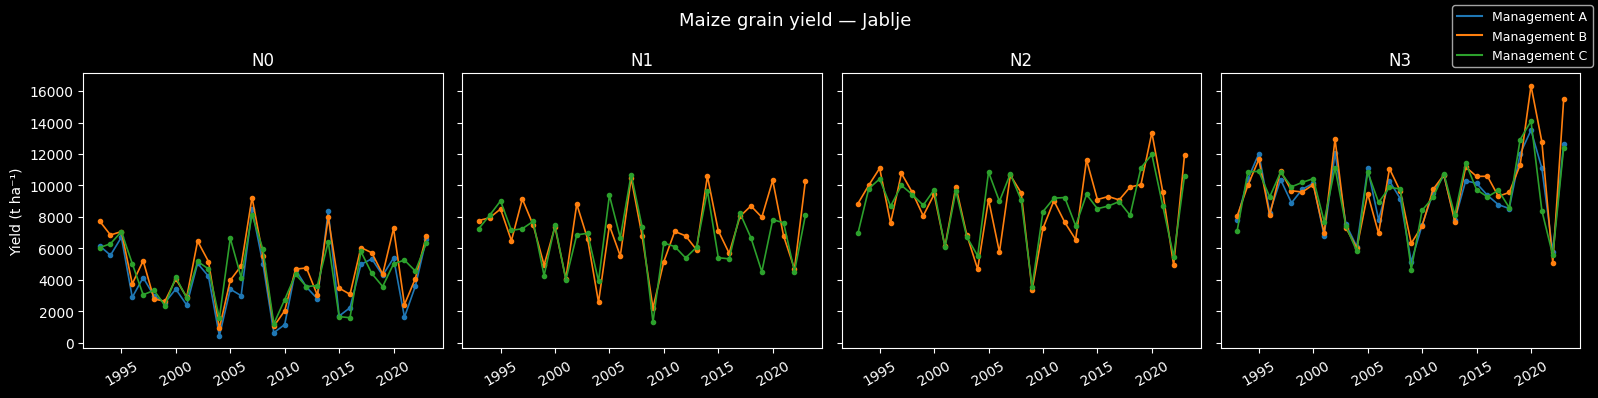

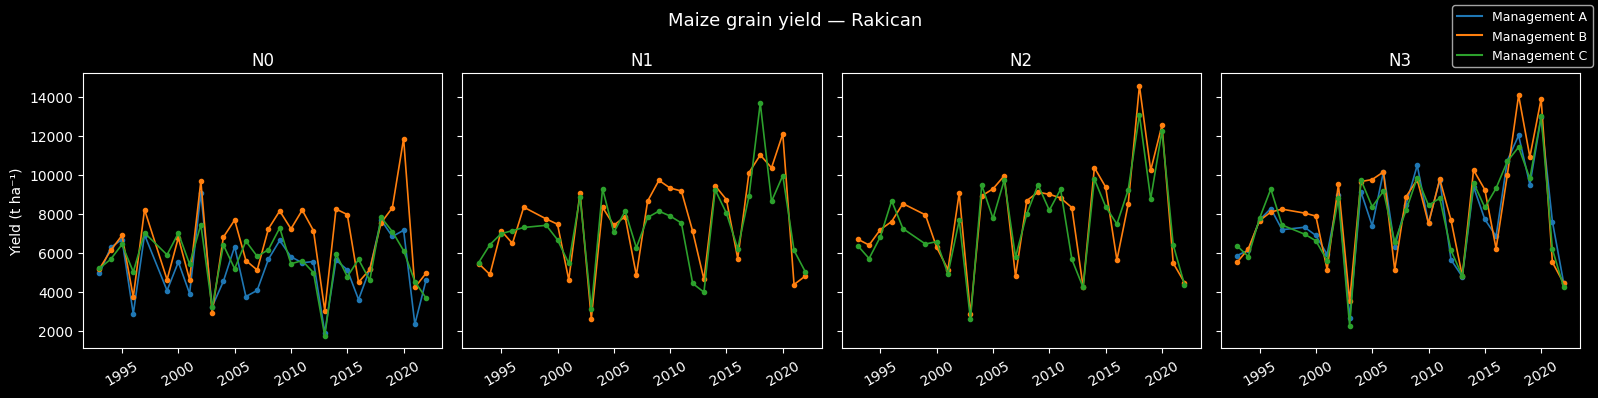

In [15]:
plot_observed_yield(yield_df, "grain")

[<Figure size 1600x400 with 4 Axes>, <Figure size 1600x400 with 4 Axes>]

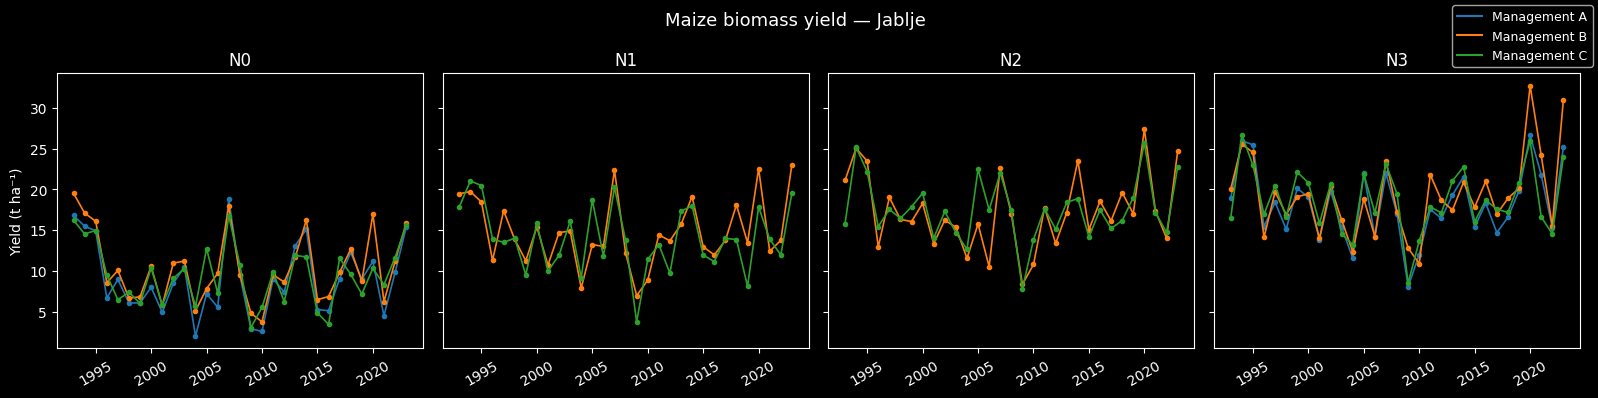

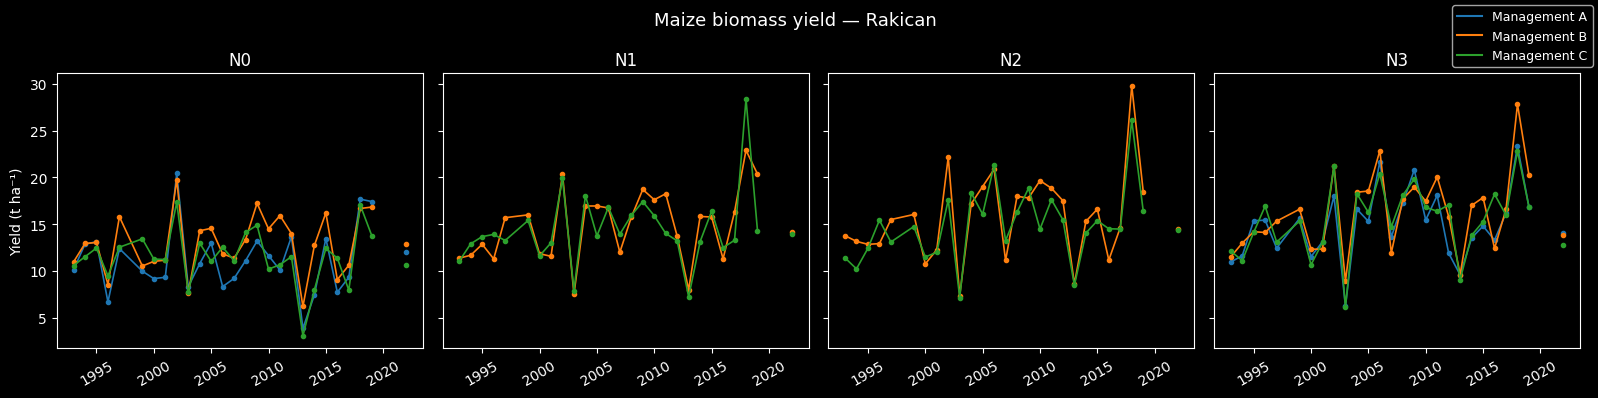

In [12]:
plot_observed_yield(yield_df, "biomass")

## Harvest Index

The harvest index (HI) is the fraction of above-ground biomass partitioned into grain:

$$HI = \frac{\text{grain}}{\text{grain} + \text{straw}}$$

In [46]:
hi_df = (
    yield_df
    .pivot_table(index=["location", "year", "management", "fertilization"], columns="product", values="yield")
    .reset_index()
)
hi_df.loc[:, "hi"] = hi_df["grain"] / (hi_df["grain"] + hi_df["straw"])
hi_df

product,location,year,management,fertilization,grain,straw,hi
0,jablje,1993,A,N0,6.163,10.628,0.367042
1,jablje,1993,A,N3,7.830,11.104,0.413542
2,jablje,1993,B,N0,7.734,11.785,0.396229
3,jablje,1993,B,N1,7.766,11.688,0.399198
4,jablje,1993,B,N2,8.841,12.243,0.419323
...,...,...,...,...,...,...,...
595,rakican,2022,B,N3,4.451,9.439,0.320446
596,rakican,2022,C,N0,3.683,7.003,0.344657
597,rakican,2022,C,N1,5.034,8.964,0.359623
598,rakican,2022,C,N2,4.376,9.961,0.305224


In [47]:
hi_df.groupby(["location", "management", "fertilization"])["hi"].describe().round(3)

count   mean    std    min    25%    50%  \
location management fertilization                                             
jablje   A          N0              31.0  0.431  0.095  0.210  0.385  0.445   
                    N3              31.0  0.526  0.073  0.377  0.487  0.515   
         B          N0              31.0  0.449  0.101  0.178  0.398  0.452   
                    N1              31.0  0.480  0.082  0.316  0.432  0.478   
                    N2              31.0  0.510  0.078  0.351  0.464  0.505   
                    N3              31.0  0.510  0.071  0.325  0.481  0.503   
         C          N0              31.0  0.463  0.081  0.275  0.404  0.470   
                    N1              31.0  0.479  0.071  0.346  0.429  0.479   
                    N2              31.0  0.502  0.064  0.372  0.462  0.498   
                    N3              31.0  0.509  0.065  0.382  0.480  0.505   
rakican  A          N0              27.0  0.477  0.081  0.381  0.421  0.467   
                    N3              27.0  0.513  0.071  0.317  0.479  0.504   
         B          N0              27.0  0.488  0.057  0.383  0.462  0.489   
                    N1              27.0  0.499  0.075  0.341  0.458  0.505   
                    N2              27.0  0.498  0.073  0.309  0.471  0.488   
                    N3              27.0  0.497  0.068  0.320  0.463  0.501   
         C          N0              27.0  0.500  0.078  0.345  0.449  0.493   
                    N1              27.0  0.501  0.080  0.336  0.474  0.497   
                    N2              27.0  0.503  0.084  0.305  0.447  0.515   
                    N3              27.0  0.506  0.086  0.331  0.450  0.514   

                                     75%    max  
location management fertilization                
jablje   A          N0             0.484  0.594  
                    N3             0.576  0.659  
         B          N0             0.511  0.615  
                    N1             0.551  0.600  
                    N2             0.569  0.675  
                    N3             0.557  0.681  
         C          N0             0.512  0.631  
                    N1             0.543  0.589  
                    N2             0.560  0.611  
                    N3             0.545  0.628  
rakican  A          N0             0.506  0.756  
                    N3             0.537  0.693  
         B          N0             0.512  0.647  
                    N1             0.551  0.630  
                    N2             0.551  0.678  
                    N3             0.532  0.640  
         C          N0             0.528  0.745  
                    N1             0.526  0.701  
                    N2             0.556  0.696  
                    N3             0.546  0.694

Mean harvest index for

jablje A-N0 is 0.431 with std 0.09

rakican A-N0 is 0.477 with std 0.08

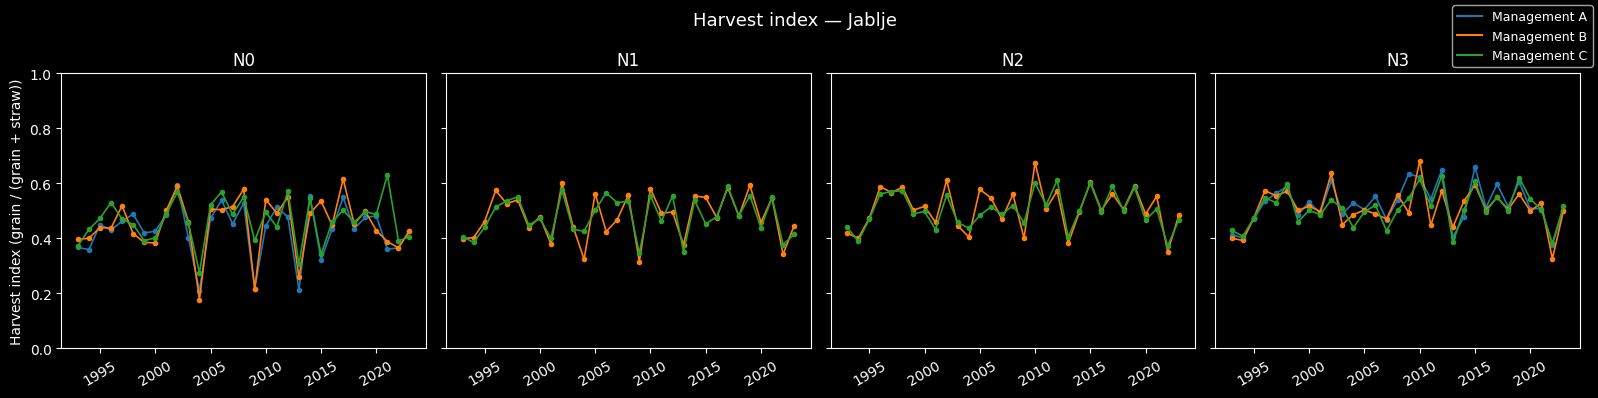

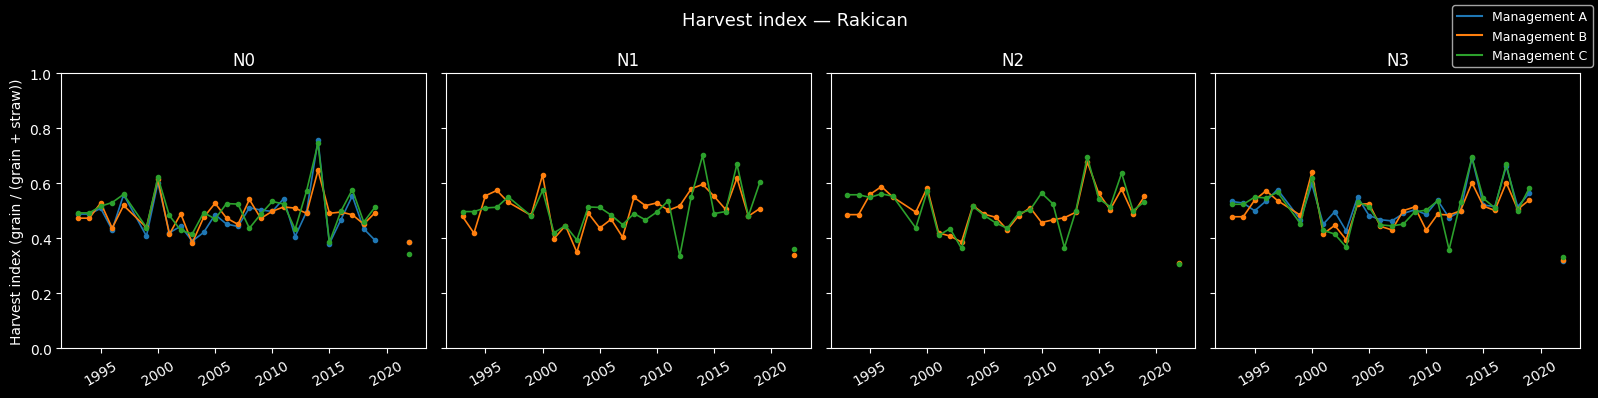

In [50]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

managements = sorted(hi_df["management"].unique())
fertilizations = sorted(hi_df["fertilization"].unique())
locations_list = sorted(hi_df["location"].unique())

colors = dict(zip(managements, ["tab:blue", "tab:orange", "tab:green"]))
color_handles = [
    mlines.Line2D([], [], color=colors[m], linewidth=1.5, label=f"Management {m}")
    for m in managements
]

for loc in locations_list:
    fig, axes = plt.subplots(1, len(fertilizations), figsize=(16, 4), sharey=True)
    for ax, fert in zip(axes, fertilizations):
        sub = hi_df[(hi_df["location"] == loc) & (hi_df["fertilization"] == fert)]
        for mgmt in managements:
            s = sub[sub["management"] == mgmt]
            if s.empty:
                continue
            ax.plot(s["year"], s["hi"], color=colors[mgmt], marker="o", markersize=3, linewidth=1.2)
        ax.set_title(fert)
        ax.set_ylim(0, 1)
        if ax is axes[0]:
            ax.set_ylabel("Harvest index (grain / (grain + straw))")
        ax.tick_params(axis="x", rotation=30)

    fig.legend(handles=color_handles, loc="upper right", fontsize=9)
    fig.suptitle(f"Harvest index — {loc.capitalize()}", fontsize=13)
    fig.tight_layout()
    plt.show()

[<Figure size 1600x400 with 4 Axes>, <Figure size 1600x400 with 4 Axes>]

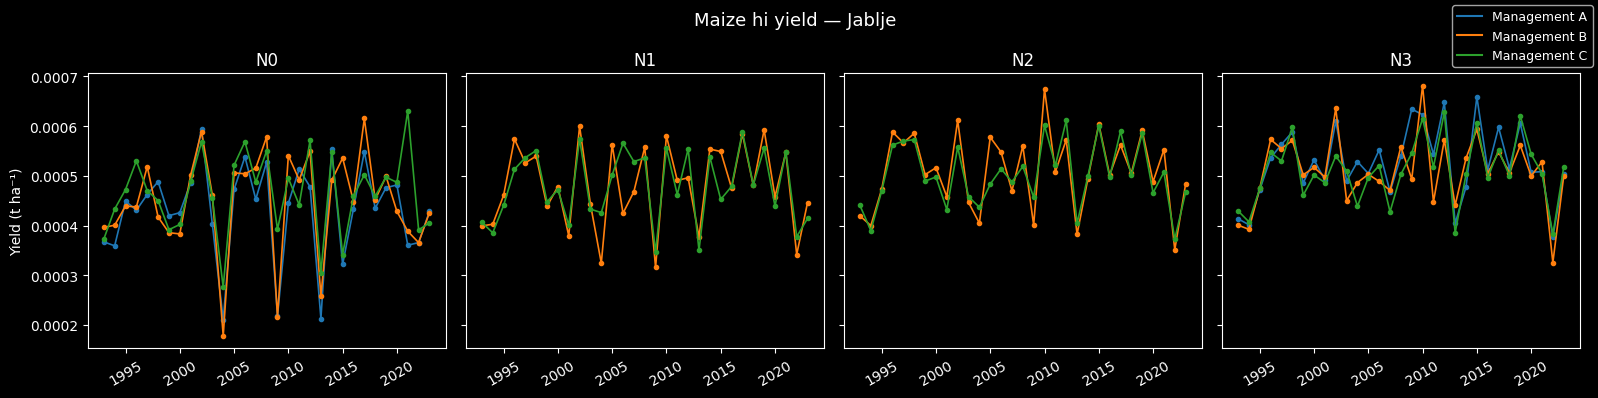

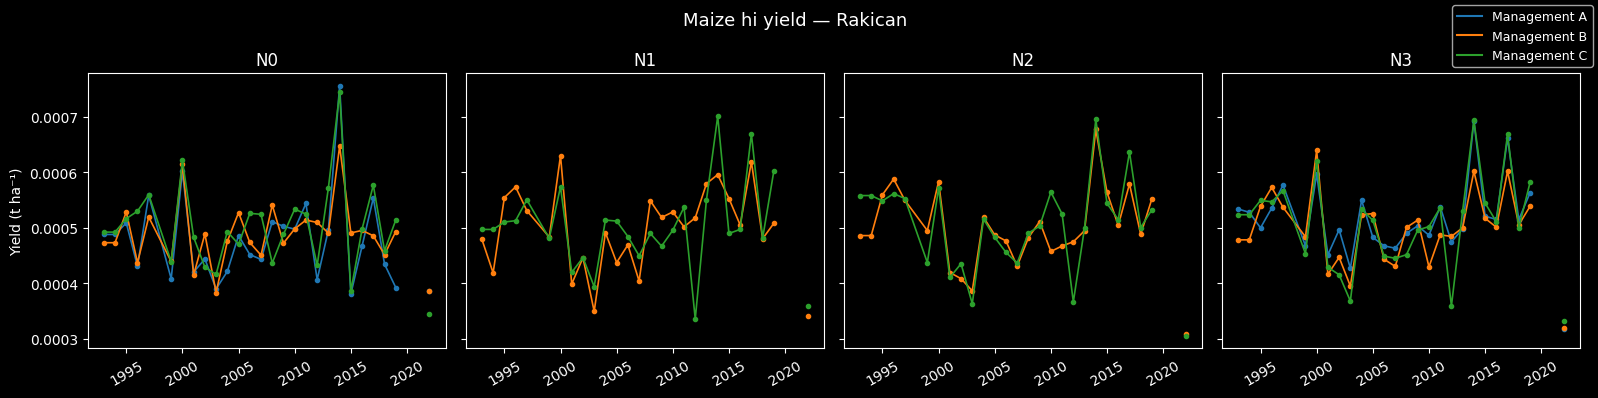

In [13]:
plot_observed_yield(yield_df, "hi")